In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast

In [35]:
directors = pd.read_csv('director_list.csv')

print(directors.head())

results = []

for i in range(0,10):

    df = pd.read_csv(f"director_{i+1}.csv")

    # sort movies by year
    df = df.sort_values('release_year')

    # latest movie
    latest = df.iloc[-1]

    # historical movies
    historical = df.iloc[:-1]

    hist_avg_score = historical["avg_score"].mean()
    hist_avg_roi  = (historical['revenue'] / historical['budget']).mean()
    hist_avg_revenue = historical['revenue'].mean()
    hist_votes = historical['imdb_vote_count'].sum()

    new_score = latest['avg_score']
    new_roi = latest['revenue']/latest['budget']
    new_revenue = latest['revenue']
    new_votes = latest['imdb_vote_count']
    print(directors['name'][i])

    results.append({
        'director' : directors['name'][i],
        'hist_avg_score' : hist_avg_score,
        'hist_avg_roi' : hist_avg_roi,
        'hist_avg_revenue' : hist_avg_revenue,
        'hist_total_votes' : hist_votes,
        'new_score' : new_score,
        'new_roi' : new_roi,
        'new_revenue' : new_revenue,
        'new_votes' : new_votes 
    })

analysis_df = pd.DataFrame(results)

corr = analysis_df.corr(numeric_only=True)
print(corr)

   id               name  avg_score  total_vote_count  \
0   1  Christopher Nolan       8.05          18012558   
1   2    Martin Scorsese       7.97          11438197   
2   3   Steven Spielberg       7.43          15703299   
3   4      Taika Waititi       7.25           2218502   
4   5      James Cameron       7.74           7217264   

   latest_movie_release_year  tmdb_id    imdb_id  directed_movie_count  
0                       2023      525  nm0634240                    12  
1                       2023     1032  nm0000217                    22  
2                       2022      488  nm0000229                    34  
3                       2023    55934  nm0169806                     6  
4                       2025     2710  nm0000116                     9  
Christopher Nolan
Martin Scorsese
Steven Spielberg
Taika Waititi
James Cameron
Ryan Coogler
Hayao Miyazaki
Guillermo del Toro
Wes Anderson
Edgar Wright
                  hist_avg_score  hist_avg_roi  hist_avg_revenue  \

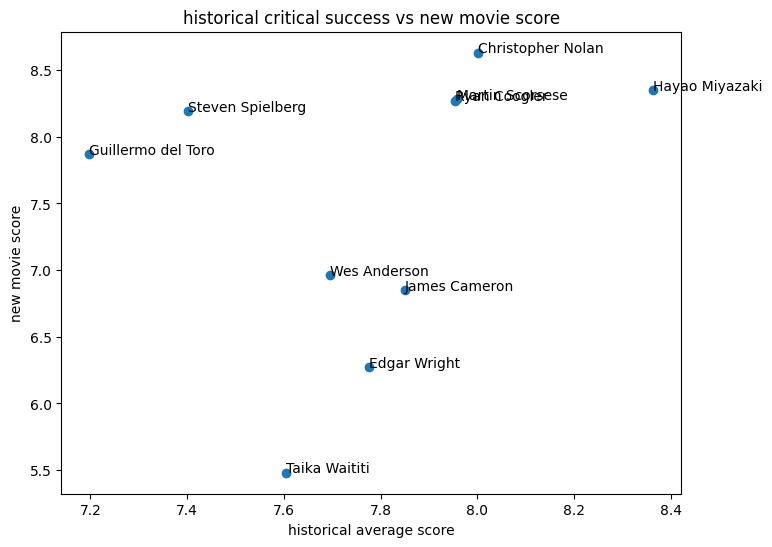

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(analysis_df['hist_avg_score'], analysis_df['new_score'])

for i, director in enumerate(analysis_df['director']):
    plt.text(
        analysis_df['hist_avg_score'][i],
        analysis_df['new_score'][i],
        director
    )

plt.xlabel('historical average score')
plt.ylabel('new movie score')
plt.title('historical critical success vs new movie score')

plt.show()

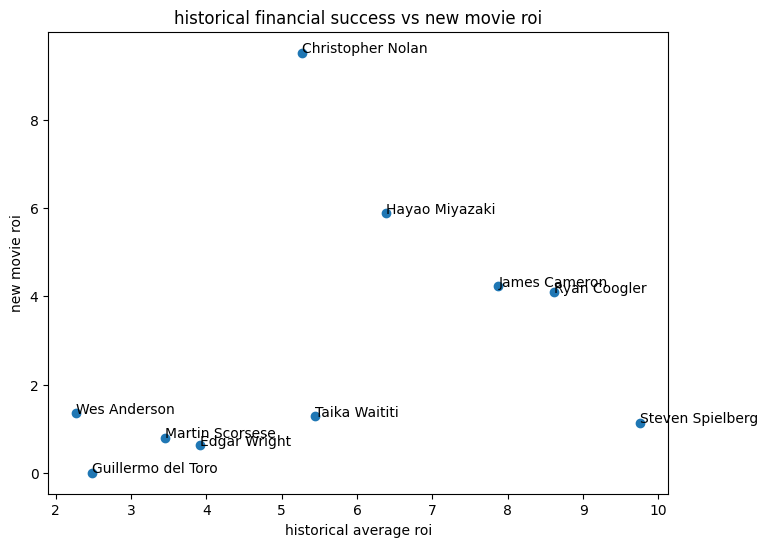

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(analysis_df['hist_avg_roi'], analysis_df['new_roi'])

for i, director in enumerate(analysis_df['director']):
    plt.text(
        analysis_df['hist_avg_roi'][i],
        analysis_df['new_roi'][i],
        director
    )

plt.xlabel('historical average roi')
plt.ylabel('new movie roi')
plt.title('historical financial success vs new movie roi')

plt.show()

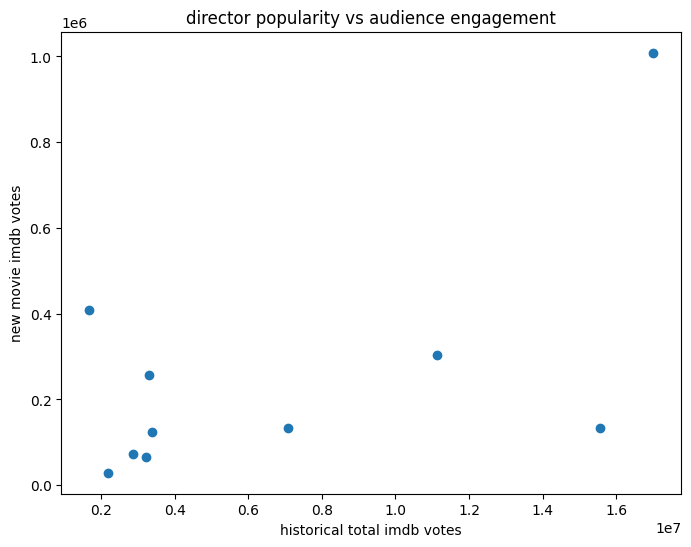

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(analysis_df['hist_total_votes'], analysis_df['new_votes'])

plt.xlabel('historical total imdb votes')
plt.ylabel('new movie imdb votes')
plt.title('director popularity vs audience engagement')

plt.show()

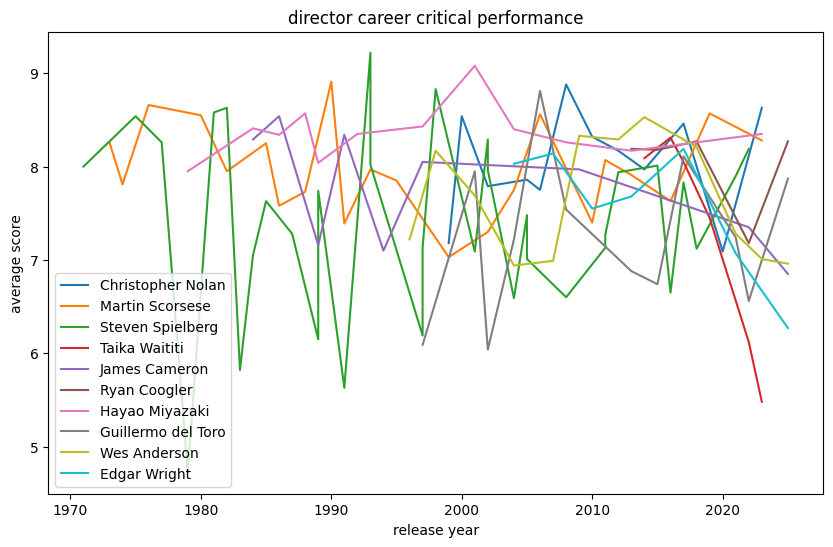

In [37]:
plt.figure(figsize=(10,6))

for i in range(1,11):
    df = pd.read_csv(f'director_{i}.csv')
    df = df.sort_values('release_year')

    plt.plot(df['release_year'], df['avg_score'], label=directors['name'][i-1])

plt.xlabel('release year')
plt.ylabel('average score')
plt.title('director career critical performance')

plt.legend()
plt.show()



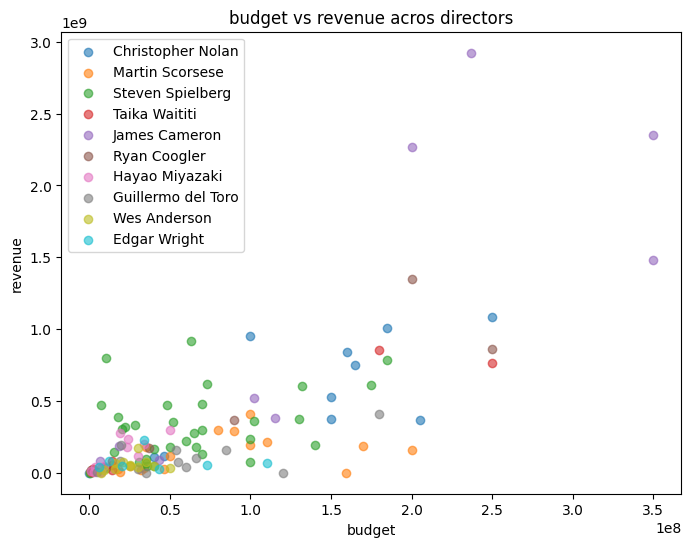

In [38]:
plt.figure(figsize=(8,6))

for i in range(1,11):
    df = pd.read_csv(f'director_{i}.csv')

    plt.scatter(df['budget'], df['revenue'], alpha=0.6, label=directors['name'][i-1])

plt.xlabel('budget')
plt.ylabel('revenue')
plt.title('budget vs revenue acros directors')

plt.legend()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

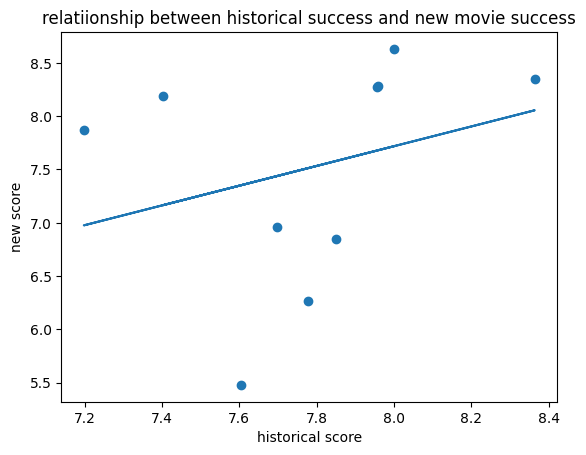

In [ ]:
x = analysis_df['hist_avg_score']
y= analysis_df['new_score']

m, b = np.polyfit(x,y,1)

plt.scatter(x,y)
plt.plot(x, m*x + b)

plt.xlabel('historical score')
plt.ylabel('new score')
plt.title('relationship between historical success and new movie success')

plt.show